# 02 — Baseline

Late-rate lookup baseline on the Phase 3 gold snapshot (`make baseline`). Reads `metrics.json` from MinIO; no row data is shown.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Settings read `.env` from the working directory: run from the repo root.
if Path.cwd().name == "notebooks":
    os.chdir("..")

from dbdelay.config import get_settings
from dbdelay.storage import ObjectStore, make_s3_client

settings = get_settings()
store = ObjectStore(make_s3_client(settings), settings.data_bucket)
keys = sorted(
    k for k in store.iter_keys("gold/training_sets/") if k.endswith("baseline/metrics.json")
)
report = json.loads(store.get_bytes(keys[-1]))
report["snapshot_id"]

'2026-08-31_38b45c7a'

In [2]:
overall = {name: split["overall"] for name, split in report["splits"].items()}
pd.DataFrame(overall).round(4)

,valid,test
n,178256.0000,176628.0000
base_rate,0.2719,0.2473
brier,0.1588,0.1520
roc_auc,0.7783,0.7714
pr_auc,0.5739,0.5272
log_loss,0.4901,0.4704
ece,0.0280,0.0124


In [3]:
rows = [{"train_type": k, **v} for k, v in report["splits"]["test"]["slices"]["train_type"].items()]
pd.DataFrame(rows).sort_values("n", ascending=False).round(4)

,train_type,n,base_rate,brier,roc_auc,pr_auc,log_loss,ece
40,S,39895,0.1461,0.1187,0.6831,0.2490,0.3911,0.0152
22,ICE,34676,0.4943,0.2297,0.6674,0.6336,0.6502,0.0538
35,RE,25012,0.1818,0.1381,0.6801,0.3434,0.4435,0.0197
34,RB,15623,0.1204,0.1035,0.6715,0.2041,0.3553,0.0301
30,NX,10146,0.4082,0.2412,0.5669,0.4576,0.6758,0.0511
3,ARV,5056,0.1855,0.1443,0.6585,0.2980,0.4585,0.0183
21,IC,4375,0.3627,0.1913,0.7429,0.6487,0.5657,0.0436
15,ERB,3818,0.2237,0.1706,0.5923,0.3078,0.5256,0.0329
41,SBH,3416,0.1256,0.1095,0.5697,0.1493,0.3760,0.0199
49,VIA,2772,0.3362,0.1959,0.7117,0.5614,0.5780,0.0419


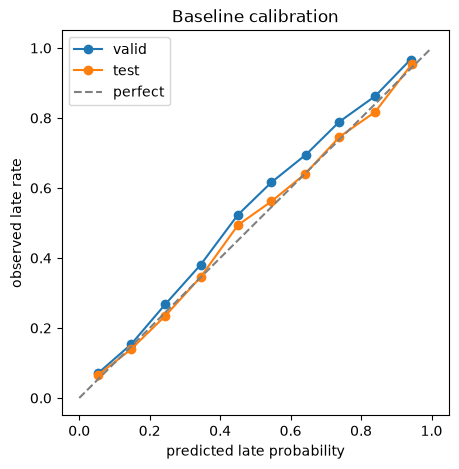

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
for name, split in report["splits"].items():
    bins = pd.DataFrame(split["calibration"])
    ax.plot(bins["mean_pred"], bins["observed_rate"], marker="o", label=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="perfect")
ax.set(
    xlabel="predicted late probability",
    ylabel="observed late rate",
    title="Baseline calibration",
)
ax.legend()
plt.show()